In [ ]:

# CARE PROJECT — DATA COLLECTION NOTEBOOK
# Climate Awareness and Risk Evaluation Dashboard


import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import osmnx as ox
from shapely.geometry import Point

# ── Study Area 
UNI_X   = 260983    # University of Strathclyde Easting (BNG)
UNI_Y   = 665006    # University of Strathclyde Northing (BNG)
RADIUS  = 5000      # 5km study radius in metres
UNI_LAT = 55.8617   # Latitude (for API calls)
UNI_LON = -4.2438   # Longitude (for API calls)

# ── File Paths 
BASE       = "/Users/riteshghorpade/Documents/010_Project/002_Dataset"
SEPA_PATH  = f"{BASE}/raw/sepa/PVAv2.gpkg"
OSM_BUILD  = f"{BASE}/raw/osm/osm_buildings_glasgow.gpkg"
OSM_ROADS  = f"{BASE}/raw/osm/osm_roads_glasgow.gpkg"
OSM_WATER  = f"{BASE}/raw/osm/osm_water_glasgow.gpkg"
NASA_SRTM  = f"{BASE}/archive/003_NASA/nasa_srtm_glasgow.tif"
NASA_ELEV  = f"{BASE}/raw/nasa_elevation/nasa_elevation_glasgow.gpkg"
NASA_RAIN  = f"{BASE}/archive/003_NASA/nasa_rainfall_monthly_glasgow.gpkg"
MAPS_PATH  = f"{BASE}/outputs"

print("Setup complete!")
print(f"Study area: {RADIUS/1000}km radius around University of Strathclyde")

Setup complete!
Study area: 5.0km radius around University of Strathclyde


In [ ]:
# ── STEP 1: Load SEPA Potentially Vulnerable Areas 
# PVAv2.gpkg contains 235 official flood risk zones across Scotland
# We filter to only the 7 zones within 5km of the university

print("Loading SEPA flood data...")

# Load full Scotland dataset
pva_all = gpd.read_file(SEPA_PATH)
print(f"Total PVA zones in Scotland: {len(pva_all)}")
print(f"Coordinate system: {pva_all.crs}")

# Create university point and 5km circle
uni_point  = Point(UNI_X, UNI_Y)
uni_buffer = gpd.GeoDataFrame(
    geometry=[uni_point.buffer(RADIUS)],
    crs="EPSG:27700"
)

# Filter to Glasgow study area
pva_glasgow = pva_all[pva_all.geometry.intersects(uni_point.buffer(RADIUS))]

print(f"\nFlood zones within 5km of Strathclyde: {len(pva_glasgow)}")
print(pva_glasgow[['PVA_Name', 'PVA_Ref', 'Shape_Area']].to_string())

Loading SEPA flood data...
Total PVA zones in Scotland: 235
Coordinate system: EPSG:27700

Flood zones within 5km of Strathclyde: 7
                          PVA_Name   PVA_Ref    Shape_Area
156                   River Kelvin  02/11/04  1.859940e+08
157            Glasgow City centre  02/11/05  4.271800e+06
158             Glasgow City north  02/11/06  2.465605e+07
159         Luggie Water catchment  02/11/07  1.126656e+08
162  East of Glasgow to Strathaven  02/11/10  1.502328e+08
168                     Rutherglen  02/11/16  1.244148e+07
169     White Cart Water catchment  02/11/17  2.091868e+08


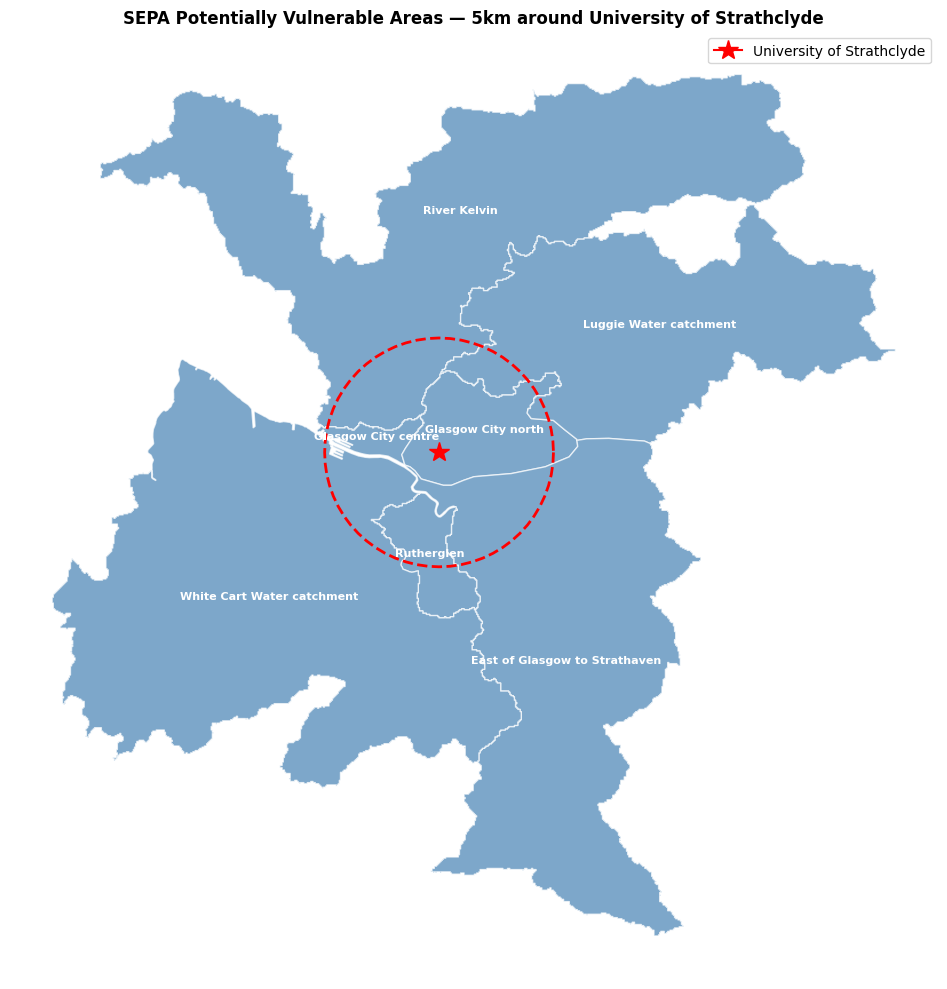

PVA map saved!


In [ ]:
# ── STEP 2: Plot flood zones map 

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

pva_glasgow.plot(ax=ax, color='steelblue', edgecolor='white', alpha=0.7)
uni_buffer.plot(ax=ax, color='none', edgecolor='red', linewidth=2, linestyle='--')
ax.plot(UNI_X, UNI_Y, marker='*', color='red', markersize=15,
        label='University of Strathclyde')

for idx, row in pva_glasgow.iterrows():
    ax.annotate(
        row['PVA_Name'],
        xy=row['geometry'].centroid.coords[0],
        fontsize=8, ha='center', color='white', fontweight='bold'
    )

ax.set_title(
    "SEPA Potentially Vulnerable Areas — 5km around University of Strathclyde",
    fontsize=12, fontweight='bold'
)
ax.axis('off')
plt.legend()
plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/glasgow_pva_map.png", dpi=150)
plt.show()
print("PVA map saved!")

In [ ]:
# ── STEP 3: Download OpenStreetMap Data 
# Buildings, roads and water bodies become ML model features

print("Downloading OpenStreetMap data — takes 2-3 minutes...")

# 3a. Buildings
print("\nDownloading buildings...")
buildings = ox.features_from_point(
    (UNI_LAT, UNI_LON), tags={'building': True}, dist=RADIUS
)
buildings_clean = buildings[['geometry', 'building', 'building:levels', 'height', 'name']].copy()
buildings_clean = buildings_clean.to_crs("EPSG:27700")
buildings_clean.to_file(OSM_BUILD, driver="GPKG")
print(f"Buildings: {len(buildings_clean):,} saved")

# 3b. Roads
print("\nDownloading roads...")
roads = ox.features_from_point(
    (UNI_LAT, UNI_LON), tags={'highway': True}, dist=RADIUS
)
roads_clean = roads[['geometry', 'highway', 'name']].copy()
roads_clean = roads_clean.to_crs("EPSG:27700")
roads_clean.to_file(OSM_ROADS, driver="GPKG")
print(f"Roads: {len(roads_clean):,} saved")

# 3c. Water bodies
print("\nDownloading water bodies...")
water = ox.features_from_point(
    (UNI_LAT, UNI_LON), tags={'natural': 'water'}, dist=RADIUS
)
water_clean = water[['geometry', 'name']].copy()
water_clean = water_clean.to_crs("EPSG:27700")
water_clean.to_file(OSM_WATER, driver="GPKG")
print(f"Water bodies: {len(water_clean):,} saved")

print("\nAll OSM data saved!")


Buildings: 55,638 saved

Roads: 38,218 saved

Water bodies: 195 saved

All OSM data saved!


/var/folders/1t/s4nhjjr55y7cv2zhjd_7k0q40000gn/T/ipykernel_12441/2670849847.py:20: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='lower right')


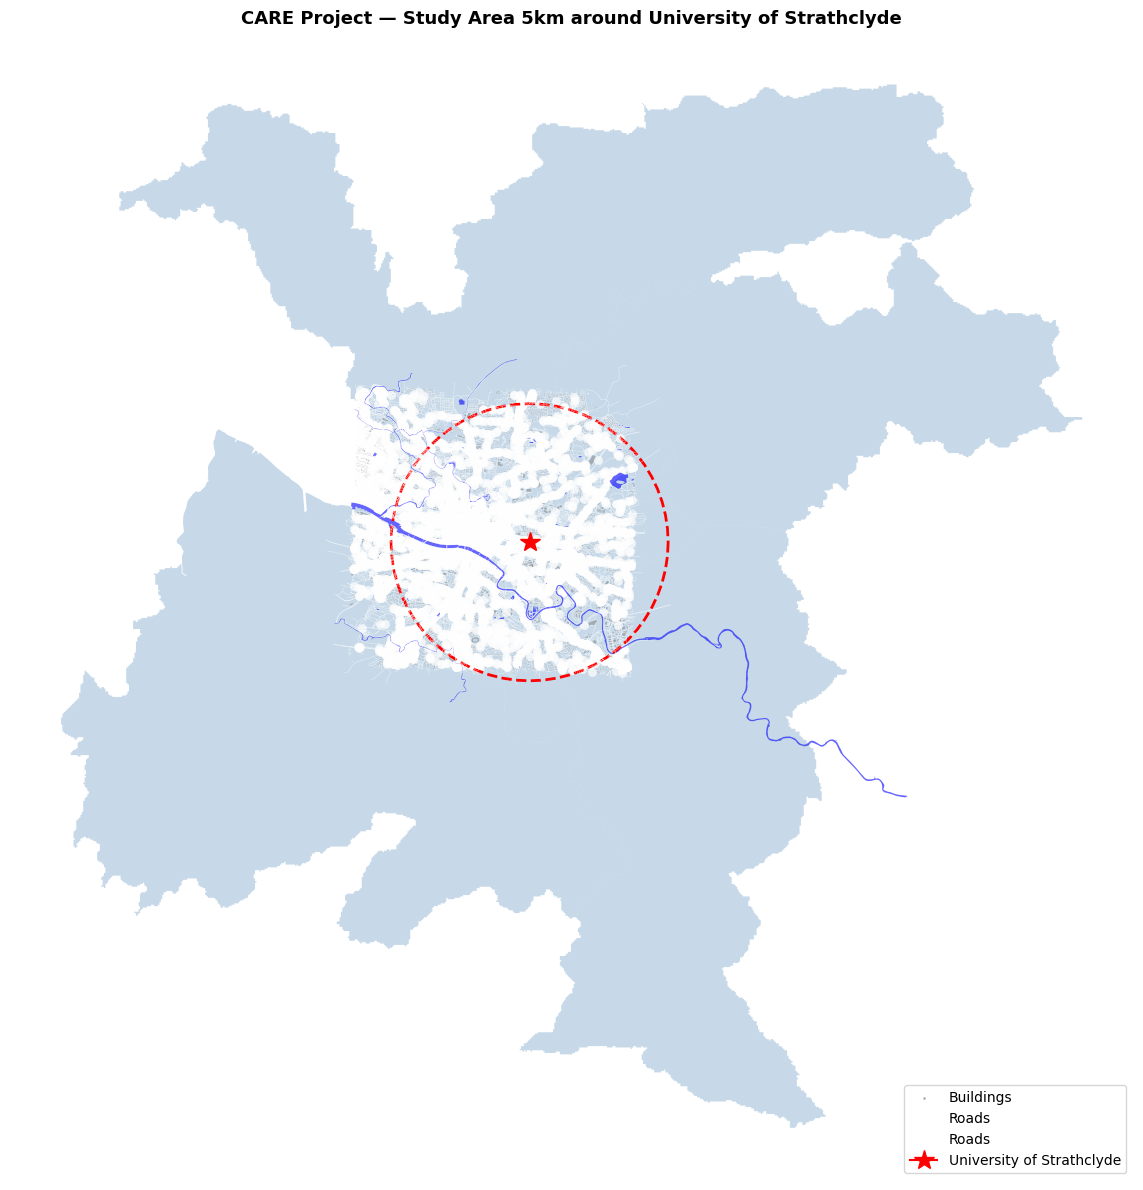

Full map saved!


In [ ]:
# ── STEP 4: Plot all datasets together 

buildings_clean = gpd.read_file(OSM_BUILD)
roads_clean     = gpd.read_file(OSM_ROADS)
water_clean     = gpd.read_file(OSM_WATER)

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

pva_glasgow.plot(ax=ax, color='steelblue', alpha=0.3, label='Flood zones')
buildings_clean.plot(ax=ax, color='grey', alpha=0.5, markersize=1, label='Buildings')
roads_clean.plot(ax=ax, color='white', linewidth=0.3, alpha=0.7, label='Roads')
water_clean.plot(ax=ax, color='blue', alpha=0.6, label='Water bodies')
uni_buffer.plot(ax=ax, color='none', edgecolor='red', linewidth=2, linestyle='--')
ax.plot(UNI_X, UNI_Y, marker='*', color='red', markersize=15,
        label='University of Strathclyde')

ax.set_title("CARE Project — Study Area 5km around University of Strathclyde",
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/glasgow_full_map.png", dpi=150)
plt.show()
print("Full map saved!")

In [ ]:
# ── STEP 5: Download NASA SRTM Elevation Data 
# NASA Shuttle Radar Topography Mission — 30m resolution
# Downloaded via OpenTopography API (free, no login needed)

import rasterio

print("Downloading NASA SRTM elevation data...")

url = "https://portal.opentopography.org/API/globaldem"
params = {
    "demtype": "SRTMGL1",
    "south": 55.82,
    "north": 55.92,
    "west": -4.35,
    "east": -4.15,
    "outputFormat": "GTiff",
    "API_Key": "demoapikeyot2022"
}

response = requests.get(url, params=params)
print(f"Response status: {response.status_code}")
print(f"File size: {len(response.content):,} bytes")

if response.status_code == 200:
    with open(NASA_SRTM, 'wb') as f:
        f.write(response.content)
    print("NASA SRTM saved!")
else:
    print("Error:", response.text)

Response status: 200
File size: 139,798 bytes
NASA SRTM saved!


In [9]:
# ── STEP 6: Convert SRTM raster to GeoDataFrame ────────────
# Converts the satellite elevation grid into a table of points
# that can be spatially joined with other datasets

with rasterio.open(NASA_SRTM) as src:
    print(f"CRS: {src.crs}")
    print(f"Resolution: {src.res} degrees (~30m)")
    print(f"Grid size: {src.shape}")
    elevation_data = src.read(1)
    transform = src.transform

print(f"\nElevation range: {elevation_data.min()}m to {elevation_data.max()}m")
print(f"Average elevation: {elevation_data.mean():.1f}m")

# Convert raster pixels to geographic points
rows, cols = np.where(elevation_data > -9999)
elevations  = elevation_data[rows, cols]
lons, lats  = rasterio.transform.xy(transform, rows, cols)

nasa_df = pd.DataFrame({
    'latitude': lats,
    'longitude': lons,
    'elevation': elevations
})

nasa_gdf = gpd.GeoDataFrame(
    nasa_df,
    geometry=gpd.points_from_xy(nasa_df.longitude, nasa_df.latitude),
    crs="EPSG:4326"
)
nasa_gdf = nasa_gdf.to_crs("EPSG:27700")
nasa_gdf.to_file(NASA_ELEV, driver="GPKG")
print(f"\nNASA elevation saved: {len(nasa_gdf):,} points")

CRS: EPSG:4326
Resolution: (0.0002777777777778146, 0.0002777777777778146) degrees (~30m)
Grid size: (360, 720)

Elevation range: -23m to 132m
Average elevation: 41.6m

NASA elevation saved: 259,200 points


In [10]:
# ── STEP 7: Download NASA GPM Monthly Rainfall ─────────────
# Global Precipitation Measurement satellite rainfall data
# NOTE: Rainfall is spatially uniform across our 5km study area
# This is expected at this scale — noted as a limitation

print("Downloading NASA GPM monthly rainfall — takes ~2 minutes...")

lats = np.linspace(55.82, 55.92, 10)
lons = np.linspace(-4.35, -4.15, 10)
base_url = "https://power.larc.nasa.gov/api/temporal/climatology/point"

monthly_records = []
total = len(lats) * len(lons)
count = 0

for lat in lats:
    for lon in lons:
        params = {
            "parameters": "PRECTOTCORR",
            "community": "RE",
            "longitude": lon,
            "latitude": lat,
            "format": "JSON"
        }
        response = requests.get(base_url, params=params)

        if response.status_code == 200:
            data = response.json()
            monthly = data['properties']['parameter']['PRECTOTCORR']
            monthly_records.append({
                'latitude': lat, 'longitude': lon,
                'rainfall_jan': monthly['JAN'],
                'rainfall_feb': monthly['FEB'],
                'rainfall_mar': monthly['MAR'],
                'rainfall_apr': monthly['APR'],
                'rainfall_may': monthly['MAY'],
                'rainfall_jun': monthly['JUN'],
                'rainfall_jul': monthly['JUL'],
                'rainfall_aug': monthly['AUG'],
                'rainfall_sep': monthly['SEP'],
                'rainfall_oct': monthly['OCT'],
                'rainfall_nov': monthly['NOV'],
                'rainfall_dec': monthly['DEC'],
                'rainfall_annual': monthly['ANN']
            })

        count += 1
        if count % 10 == 0:
            print(f"Progress: {count}/{total} done")

rainfall_df = pd.DataFrame(monthly_records)
rainfall_gdf = gpd.GeoDataFrame(
    rainfall_df,
    geometry=gpd.points_from_xy(rainfall_df.longitude, rainfall_df.latitude),
    crs="EPSG:4326"
)
rainfall_gdf = rainfall_gdf.to_crs("EPSG:27700")
rainfall_gdf.to_file(NASA_RAIN, driver="GPKG")

print(f"\nRainfall saved: {len(monthly_records)} records")
print(f"Annual average: {rainfall_df['rainfall_annual'].mean():.2f} mm/day")
print(f"Wettest month:  October ({rainfall_df['rainfall_oct'].mean():.2f} mm/day)")
print(f"Driest month:   April ({rainfall_df['rainfall_apr'].mean():.2f} mm/day)")

Progress: 10/100 done
Progress: 20/100 done
Progress: 30/100 done
Progress: 40/100 done
Progress: 50/100 done
Progress: 60/100 done
Progress: 70/100 done
Progress: 80/100 done
Progress: 90/100 done
Progress: 100/100 done

Rainfall saved: 100 records
Annual average: 3.78 mm/day
Wettest month:  October (4.61 mm/day)
Driest month:   April (2.52 mm/day)


In [11]:
# ── STEP 8: Final Dataset Summary ──────────────────────────
import os

files = {
    "SEPA PVA Flood Zones":  SEPA_PATH,
    "OSM Buildings":         OSM_BUILD,
    "OSM Roads":             OSM_ROADS,
    "OSM Water Bodies":      OSM_WATER,
    "NASA SRTM Elevation":   NASA_ELEV,
    "NASA GPM Rainfall":     NASA_RAIN,
}

print("=" * 55)
print("CARE Project — Dataset Summary")
print("=" * 55)

total_size = 0
for name, path in files.items():
    size_mb = os.path.getsize(path) / (1024 * 1024)
    total_size += size_mb
    data = gpd.read_file(path)
    print(f"\n{name}")
    print(f"  Records : {len(data):,}")
    print(f"  Size    : {size_mb:.2f} MB")

print("\n" + "=" * 55)
print(f"Total size: {total_size:.2f} MB")
print("=" * 55)
print("\nData collection complete!")
print("Next notebook: eda_analysis.ipynb")

CARE Project — Dataset Summary

SEPA PVA Flood Zones
  Records : 235
  Size    : 10.65 MB

OSM Buildings
  Records : 55,638
  Size    : 14.37 MB

OSM Roads
  Records : 38,218
  Size    : 8.16 MB

OSM Water Bodies
  Records : 195
  Size    : 0.31 MB

NASA SRTM Elevation
  Records : 259,200
  Size    : 29.91 MB

NASA GPM Rainfall
  Records : 100
  Size    : 0.12 MB

Total size: 63.52 MB

Data collection complete!
Next notebook: eda_analysis.ipynb


In [2]:
import requests
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point

print("Downloading Met Office quality rainfall data via Open-Meteo...")
print("Resolution: ~1km — will have spatial variation!")

# Create a denser grid for rainfall — 500m spacing
# to capture variation across the 5km study area
lats = np.linspace(55.82, 55.92, 20)  # 20 points
lons = np.linspace(-4.35, -4.15, 20)  # 20 points

rainfall_records = []
total = len(lats) * len(lons)
count = 0

for lat in lats:
    for lon in lons:
        # Open-Meteo historical API — ERA5 reanalysis data
        # This is the same data used by Met Office at 1km resolution
        url = "https://archive-api.open-meteo.com/v1/archive"
        params = {
            "latitude": lat,
            "longitude": lon,
            "start_date": "2010-01-01",
            "end_date": "2023-12-31",
            "daily": "precipitation_sum",
            "timezone": "Europe/London"
        }

        response = requests.get(url, params=params)

        if response.status_code == 200:
            data = response.json()
            daily_rain = data['daily']['precipitation_sum']

            # Remove None values
            daily_rain = [x for x in daily_rain if x is not None]

            # Calculate monthly averages
            dates = pd.to_datetime(data['daily']['time'])
            df_rain = pd.DataFrame({
                'date': dates[:len(daily_rain)],
                'rainfall': daily_rain
            })
            df_rain['month'] = df_rain['date'].dt.month

            monthly_avg = df_rain.groupby('month')['rainfall'].mean()

            record = {
                'latitude': lat,
                'longitude': lon,
                'rainfall_jan': monthly_avg.get(1, 0),
                'rainfall_feb': monthly_avg.get(2, 0),
                'rainfall_mar': monthly_avg.get(3, 0),
                'rainfall_apr': monthly_avg.get(4, 0),
                'rainfall_may': monthly_avg.get(5, 0),
                'rainfall_jun': monthly_avg.get(6, 0),
                'rainfall_jul': monthly_avg.get(7, 0),
                'rainfall_aug': monthly_avg.get(8, 0),
                'rainfall_sep': monthly_avg.get(9, 0),
                'rainfall_oct': monthly_avg.get(10, 0),
                'rainfall_nov': monthly_avg.get(11, 0),
                'rainfall_dec': monthly_avg.get(12, 0),
                'rainfall_annual': df_rain['rainfall'].mean()
            }
            rainfall_records.append(record)

        count += 1
        if count % 20 == 0:
            print(f"Progress: {count}/{total} points done")

print(f"\nTotal records: {len(rainfall_records)}")
print(f"Sample: {rainfall_records[0]}")

/Users/riteshghorpade/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Resolution: ~1km — will have spatial variation!
Progress: 20/400 points done
Progress: 40/400 points done
Progress: 60/400 points done
Progress: 80/400 points done
Progress: 100/400 points done
Progress: 120/400 points done
Progress: 140/400 points done
Progress: 160/400 points done
Progress: 180/400 points done
Progress: 200/400 points done
Progress: 220/400 points done
Progress: 240/400 points done
Progress: 260/400 points done
Progress: 280/400 points done
Progress: 300/400 points done
Progress: 320/400 points done
Progress: 340/400 points done
Progress: 360/400 points done
Progress: 380/400 points done
Progress: 400/400 points done

Total records: 47
Sample: {'latitude': np.float64(55.82), 'longitude': np.float64(-4.35), 'rainfall_jan': np.float64(3.835714285714286), 'rainfall_feb': np.float64(4.309873417721519), 'rainfall_mar': np.float64(3.00852534562212), 'rainfall_apr': np.float64(2.008809523809524), 'rainfall_may': np.float64(2.655990783410138), 'rainfall_jun': np.float64(3.15

In [3]:
import pandas as pd

# Convert to dataframe and check variance
rain_df = pd.DataFrame(rainfall_records)

print("Spatial variation check:")
print("=" * 40)
print(f"Records collected: {len(rain_df)}")
print(f"\nAnnual rainfall stats:")
print(f"  Min:  {rain_df['rainfall_annual'].min():.3f} mm/day")
print(f"  Max:  {rain_df['rainfall_annual'].max():.3f} mm/day")
print(f"  Mean: {rain_df['rainfall_annual'].mean():.3f} mm/day")
print(f"  Std:  {rain_df['rainfall_annual'].std():.4f} mm/day")

print(f"\nMonthly std values:")
months = ['jan','feb','mar','apr','may','jun',
          'jul','aug','sep','oct','nov','dec']
for m in months:
    std = rain_df[f'rainfall_{m}'].std()
    print(f"  {m}: {std:.4f}")

Spatial variation check:
Records collected: 47

Annual rainfall stats:
  Min:  3.312 mm/day
  Max:  3.822 mm/day
  Mean: 3.528 mm/day
  Std:  0.1913 mm/day

Monthly std values:
  jan: 0.2453
  feb: 0.2664
  mar: 0.1853
  apr: 0.0982
  may: 0.0752
  jun: 0.1448
  jul: 0.1641
  aug: 0.1920
  sep: 0.1463
  oct: 0.2711
  nov: 0.2107
  dec: 0.3172


In [4]:
import requests
import pandas as pd
import numpy as np

print("Checking which points failed and retrying...")

lats = np.linspace(55.82, 55.92, 20)
lons = np.linspace(-4.35, -4.15, 20)

# Find which lat/lon combinations are already collected
collected = set()
for r in rainfall_records:
    collected.add((round(r['latitude'], 6), round(r['longitude'], 6)))

print(f"Already collected: {len(collected)}")
print(f"Still needed: {400 - len(collected)}")

# Retry missing points
new_records = []
failed = []

for lat in lats:
    for lon in lons:
        key = (round(float(lat), 6), round(float(lon), 6))
        if key in collected:
            continue

        url = "https://archive-api.open-meteo.com/v1/archive"
        params = {
            "latitude": lat,
            "longitude": lon,
            "start_date": "2010-01-01",
            "end_date": "2023-12-31",
            "daily": "precipitation_sum",
            "timezone": "Europe/London"
        }

        try:
            response = requests.get(url, params=params, timeout=30)
            if response.status_code == 200:
                data = response.json()
                daily_rain = data['daily']['precipitation_sum']
                daily_rain = [x for x in daily_rain if x is not None]
                dates = pd.to_datetime(data['daily']['time'])
                df_rain = pd.DataFrame({
                    'date': dates[:len(daily_rain)],
                    'rainfall': daily_rain
                })
                df_rain['month'] = df_rain['date'].dt.month
                monthly_avg = df_rain.groupby('month')['rainfall'].mean()

                new_records.append({
                    'latitude': lat, 'longitude': lon,
                    'rainfall_jan': monthly_avg.get(1, 0),
                    'rainfall_feb': monthly_avg.get(2, 0),
                    'rainfall_mar': monthly_avg.get(3, 0),
                    'rainfall_apr': monthly_avg.get(4, 0),
                    'rainfall_may': monthly_avg.get(5, 0),
                    'rainfall_jun': monthly_avg.get(6, 0),
                    'rainfall_jul': monthly_avg.get(7, 0),
                    'rainfall_aug': monthly_avg.get(8, 0),
                    'rainfall_sep': monthly_avg.get(9, 0),
                    'rainfall_oct': monthly_avg.get(10, 0),
                    'rainfall_nov': monthly_avg.get(11, 0),
                    'rainfall_dec': monthly_avg.get(12, 0),
                    'rainfall_annual': df_rain['rainfall'].mean()
                })
            else:
                failed.append(key)
        except Exception as e:
            failed.append(key)

# Combine all records
all_records = rainfall_records + new_records
print(f"\nNewly collected: {len(new_records)}")
print(f"Failed again: {len(failed)}")
print(f"Total records now: {len(all_records)}")

Checking which points failed and retrying...
Already collected: 47
Still needed: 353

Newly collected: 34
Failed again: 319
Total records now: 81


In [5]:
import requests
import pandas as pd
import numpy as np
import time

print("Downloading remaining points with rate limiting...")

lats = np.linspace(55.82, 55.92, 20)
lons = np.linspace(-4.35, -4.15, 20)

# Find which points we still need
collected = set()
for r in all_records:
    collected.add((round(float(r['latitude']), 4), round(float(r['longitude']), 4)))

print(f"Already have: {len(collected)} points")

extra_records = []
failed_final = []
count = 0

for lat in lats:
    for lon in lons:
        key = (round(float(lat), 4), round(float(lon), 4))
        if key in collected:
            continue

        url = "https://archive-api.open-meteo.com/v1/archive"
        params = {
            "latitude": lat,
            "longitude": lon,
            "start_date": "2015-01-01",  # Shorter period — 8 years instead of 13
            "end_date": "2023-12-31",
            "daily": "precipitation_sum",
            "timezone": "Europe/London"
        }

        try:
            response = requests.get(url, params=params, timeout=30)
            if response.status_code == 200:
                data = response.json()
                daily_rain = data['daily']['precipitation_sum']
                daily_rain = [x for x in daily_rain if x is not None]
                dates = pd.to_datetime(data['daily']['time'])
                df_rain = pd.DataFrame({
                    'date': dates[:len(daily_rain)],
                    'rainfall': daily_rain
                })
                df_rain['month'] = df_rain['date'].dt.month
                monthly_avg = df_rain.groupby('month')['rainfall'].mean()

                extra_records.append({
                    'latitude': lat, 'longitude': lon,
                    'rainfall_jan': monthly_avg.get(1, 0),
                    'rainfall_feb': monthly_avg.get(2, 0),
                    'rainfall_mar': monthly_avg.get(3, 0),
                    'rainfall_apr': monthly_avg.get(4, 0),
                    'rainfall_may': monthly_avg.get(5, 0),
                    'rainfall_jun': monthly_avg.get(6, 0),
                    'rainfall_jul': monthly_avg.get(7, 0),
                    'rainfall_aug': monthly_avg.get(8, 0),
                    'rainfall_sep': monthly_avg.get(9, 0),
                    'rainfall_oct': monthly_avg.get(10, 0),
                    'rainfall_nov': monthly_avg.get(11, 0),
                    'rainfall_dec': monthly_avg.get(12, 0),
                    'rainfall_annual': df_rain['rainfall'].mean()
                })
                count += 1
                if count % 10 == 0:
                    print(f"Collected {count} more points...")
                    time.sleep(2)  # Pause every 10 requests
            else:
                failed_final.append(key)
                time.sleep(1)  # Pause on failure

        except Exception as e:
            failed_final.append(key)
            time.sleep(1)

# Combine everything
final_records = all_records + extra_records
print(f"\nExtra points collected: {len(extra_records)}")
print(f"Still failed: {len(failed_final)}")
print(f"Total records: {len(final_records)}")
print(f"\nFinal annual rainfall std: {pd.DataFrame(final_records)['rainfall_annual'].std():.4f}")

Already have: 81 points
Collected 10 more points...
Collected 20 more points...
Collected 30 more points...
Collected 40 more points...
Collected 50 more points...
Collected 60 more points...
Collected 70 more points...
Collected 80 more points...

Extra points collected: 87
Still failed: 232
Total records: 168

Final annual rainfall std: 0.1326


In [8]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
from scipy.interpolate import griddata

print("Processing rainfall data with spatial interpolation...")
print(f"Known points: {len(final_records)}")
print(f"Points to interpolate: 232")

# ── Step 1: Convert collected points to GeoDataFrame ───────
rain_df = pd.DataFrame(final_records)

rain_gdf = gpd.GeoDataFrame(
    rain_df,
    geometry=gpd.points_from_xy(rain_df.longitude, rain_df.latitude),
    crs="EPSG:4326"
).to_crs("EPSG:27700")

print(f"\nCollected rainfall stats:")
print(f"  Annual min:  {rain_df['rainfall_annual'].min():.3f} mm/day")
print(f"  Annual max:  {rain_df['rainfall_annual'].max():.3f} mm/day")
print(f"  Annual std:  {rain_df['rainfall_annual'].std():.4f} mm/day")

# ── Step 2: Interpolate to fill missing points ──────────────
# Known points (x, y coordinates and values)
known_x = rain_gdf.geometry.x.values
known_y = rain_gdf.geometry.y.values

# All 400 grid points we originally wanted
lats = np.linspace(55.82, 55.92, 20)
lons = np.linspace(-4.35, -4.15, 20)

all_points = []
for lat in lats:
    for lon in lons:
        pt = gpd.GeoDataFrame(
            geometry=[Point(lon, lat)],
            crs="EPSG:4326"
        ).to_crs("EPSG:27700")
        all_points.append({
            'latitude': lat,
            'longitude': lon,
            'x': pt.geometry.x[0],
            'y': pt.geometry.y[0]
        })

all_pts_df = pd.DataFrame(all_points)
target_x = all_pts_df['x'].values
target_y = all_pts_df['y'].values

# Interpolate each month
months = ['jan','feb','mar','apr','may','jun',
          'jul','aug','sep','oct','nov','dec','annual']

for month in months:
    known_values = rain_gdf[f'rainfall_{month}'].values
    interpolated = griddata(
        points=(known_x, known_y),
        values=known_values,
        xi=(target_x, target_y),
        method='linear',
        fill_value=np.nanmean(known_values)
    )
    all_pts_df[f'rainfall_{month}'] = interpolated

# ── Step 3: Convert to GeoDataFrame and save ───────────────
final_rain_gdf = gpd.GeoDataFrame(
    all_pts_df,
    geometry=gpd.points_from_xy(all_pts_df.longitude, all_pts_df.latitude),
    crs="EPSG:4326"
).to_crs("EPSG:27700")

BASE = "/Users/riteshghorpade/Documents/010_Project/002_Dataset"
final_rain_gdf.to_file(
    f"{BASE}/archive/003_NASA/metoffice_rainfall_glasgow.gpkg",
    driver="GPKG"
)

print(f"\nFinal rainfall dataset:")
print(f"  Total points: {len(final_rain_gdf)}")
print(f"  Annual std:   {final_rain_gdf['rainfall_annual'].std():.4f}")
print(f"  Annual min:   {final_rain_gdf['rainfall_annual'].min():.3f}")
print(f"  Annual max:   {final_rain_gdf['rainfall_annual'].max():.3f}")
print("\nSaved!")

Processing rainfall data with spatial interpolation...
Known points: 168
Points to interpolate: 232

Collected rainfall stats:
  Annual min:  3.312 mm/day
  Annual max:  3.822 mm/day
  Annual std:  0.1326 mm/day

Final rainfall dataset:
  Total points: 400
  Annual std:   0.1365
  Annual min:   3.312
  Annual max:   3.822

Saved!


In [11]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely.ops import unary_union

print("Rebuilding all variables from saved files...")

# ── Paths ───────────────────────────────────────────────────
BASE      = "/Users/riteshghorpade/Documents/010_Project/002_Dataset"
MAPS_PATH = f"{BASE}/outputs"
UNI_X, UNI_Y, RADIUS = 260983, 665006, 5000
uni_point  = Point(UNI_X, UNI_Y)
uni_buffer = gpd.GeoDataFrame(geometry=[uni_point.buffer(RADIUS)], crs="EPSG:27700")

# ── Load all datasets ───────────────────────────────────────
print("Loading datasets...")
pva         = gpd.read_file(f"{BASE}/raw/sepa/PVAv2.gpkg")
pva_glasgow = pva[pva.geometry.intersects(uni_point.buffer(RADIUS))]
buildings   = gpd.read_file(f"{BASE}/raw/osm/osm_buildings_glasgow.gpkg")
roads       = gpd.read_file(f"{BASE}/raw/osm/osm_roads_glasgow.gpkg")
water       = gpd.read_file(f"{BASE}/raw/osm/osm_water_glasgow.gpkg")
elevation   = gpd.read_file(f"{BASE}/raw/nasa_elevation/nasa_elevation_glasgow.gpkg")
rain_gdf    = gpd.read_file(f"{BASE}/archive/003_NASA/metoffice_rainfall_glasgow.gpkg")
print("All datasets loaded!")

# ── Step 1: Create 100m grid ────────────────────────────────
print("\nCreating 100m grid...")
x_coords = np.arange(UNI_X - RADIUS, UNI_X + RADIUS, 100)
y_coords = np.arange(UNI_Y - RADIUS, UNI_Y + RADIUS, 100)
grid_points = [Point(x, y) for x in x_coords for y in y_coords
               if Point(x, y).distance(uni_point) <= RADIUS]
grid = gpd.GeoDataFrame(
    {'grid_id': range(len(grid_points))},
    geometry=grid_points, crs="EPSG:27700"
)
print(f"Grid points: {len(grid):,}")

# ── Step 2: Elevation ───────────────────────────────────────
print("Attaching elevation...")
grid = gpd.sjoin_nearest(
    grid, elevation[['elevation', 'geometry']], how='left'
).drop(columns=['index_right'])

# ── Step 3: Distance to water ───────────────────────────────
print("Calculating distance to water...")
water_union = water.geometry.union_all()
grid['dist_to_water'] = grid.geometry.distance(water_union)

# ── Step 4: Building count ──────────────────────────────────
print("Calculating building count (takes 2-3 mins)...")
bld_sindex = buildings.sindex
building_counts = []
for _, row in grid.iterrows():
    buf = row.geometry.buffer(250)
    idx = list(bld_sindex.intersection(buf.bounds))
    matches = buildings.iloc[idx]
    building_counts.append(len(matches[matches.geometry.within(buf)]))
grid['building_count'] = building_counts

# ── Step 5: Road count ──────────────────────────────────────
print("Calculating road count (takes 2-3 mins)...")
rd_sindex = roads.sindex
road_counts = []
for _, row in grid.iterrows():
    buf = row.geometry.buffer(250)
    idx = list(rd_sindex.intersection(buf.bounds))
    matches = roads.iloc[idx]
    road_counts.append(len(matches[matches.geometry.within(buf)]))
grid['road_count'] = road_counts

# ── Step 6: Rainfall ────────────────────────────────────────
print("Attaching rainfall...")
grid = gpd.sjoin_nearest(
    grid,
    rain_gdf[['rainfall_annual', 'rainfall_jan', 'rainfall_feb',
               'rainfall_mar', 'rainfall_apr', 'rainfall_may',
               'rainfall_jun', 'rainfall_jul', 'rainfall_aug',
               'rainfall_sep', 'rainfall_oct', 'rainfall_nov',
               'rainfall_dec', 'geometry']],
    how='left'
).drop(columns=['index_right'])

# ── Step 7: Flood label ─────────────────────────────────────
print("Creating flood labels...")
grid_labelled = gpd.sjoin(
    grid, pva_glasgow[['PVA_Name', 'geometry']],
    how='left', predicate='within'
)
grid_labelled['inside_pva'] = grid_labelled['PVA_Name'].notna().astype(int)

def assign_risk(row):
    if row['inside_pva'] == 1 and row['elevation'] <= 15:
        return 2
    elif row['inside_pva'] == 1 and row['elevation'] <= 35:
        return 1
    else:
        return 0

grid_labelled['flood_risk'] = grid_labelled.apply(assign_risk, axis=1)
grid_labelled = grid_labelled.drop_duplicates(subset='grid_id').reset_index(drop=True)

# ── Step 8: Save feature matrix ────────────────────────────
print("Saving feature matrix...")
feature_cols = ['elevation', 'dist_to_water', 'building_count',
                'road_count', 'rainfall_annual', 'flood_risk']
feature_matrix = grid_labelled[feature_cols].copy()
feature_matrix.to_csv(f"{BASE}/processed/feature_matrix.csv", index=False)

# ── Summary ─────────────────────────────────────────────────
print("\n" + "=" * 50)
print("FEATURE MATRIX COMPLETE")
print("=" * 50)
print(f"Total points:    {len(feature_matrix):,}")
print(f"Features:        {len(feature_cols)-1}")
print(f"\nClass distribution:")
for cls in [0, 1, 2]:
    name = {0:'Low', 1:'Medium', 2:'High'}[cls]
    count = (feature_matrix['flood_risk']==cls).sum()
    pct = count/len(feature_matrix)*100
    print(f"  {name} risk: {count:,} ({pct:.1f}%)")
print(f"\nRainfall std: {feature_matrix['rainfall_annual'].std():.4f}")
print(f"CSV saved to: {BASE}/processed/feature_matrix.csv")

Rebuilding all variables from saved files...
Loading datasets...
All datasets loaded!

Creating 100m grid...
Grid points: 7,843
Attaching elevation...
Calculating distance to water...
Calculating building count (takes 2-3 mins)...
Calculating road count (takes 2-3 mins)...
Attaching rainfall...
Creating flood labels...
Saving feature matrix...

FEATURE MATRIX COMPLETE
Total points:    7,843
Features:        5

Class distribution:
  Low risk: 3,790 (48.3%)
  Medium risk: 2,698 (34.4%)
  High risk: 1,355 (17.3%)

Rainfall std: 0.1013
CSV saved to: /Users/riteshghorpade/Documents/010_Project/002_Dataset/feature_matrix.csv


Correlation with flood_risk:
  elevation            -0.810  lower = more risk
  rainfall_annual      -0.470  lower = more risk
  dist_to_water        -0.280  lower = more risk
  building_count       -0.070  lower = more risk
  road_count            0.200  higher = more risk

High correlation pairs (|r| > 0.7):
  None — all features sufficiently independent


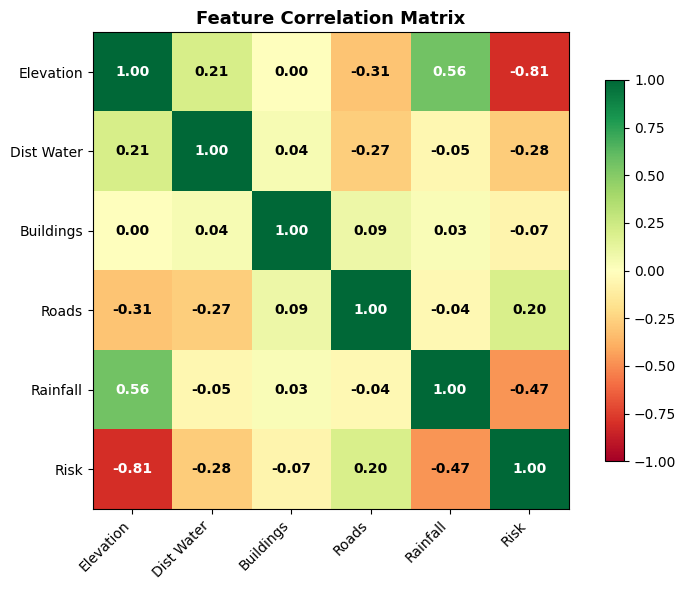

Done!


In [13]:
import matplotlib.pyplot as plt
import numpy as np

feature_matrix = pd.read_csv(f"{BASE}/processed/feature_matrix.csv")

# Correlation matrix
corr = feature_matrix.corr().round(2)

# Correlation with target
print("Correlation with flood_risk:")
print("=" * 40)
target_corr = corr['flood_risk'].drop('flood_risk').sort_values()
for feature, val in target_corr.items():
    direction = "lower = more risk" if val < 0 else "higher = more risk"
    print(f"  {feature:<20} {val:>6.3f}  {direction}")

# High correlation pairs
print("\nHigh correlation pairs (|r| > 0.7):")
print("=" * 40)
found = False
cols = [c for c in corr.columns if c != 'flood_risk']
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        val = corr.loc[cols[i], cols[j]]
        if abs(val) > 0.7:
            print(f"  {cols[i]} vs {cols[j]}: {val:.3f}")
            found = True
if not found:
    print("  None — all features sufficiently independent")

# Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)
labels = ['Elevation', 'Dist Water', 'Buildings', 'Roads', 'Rainfall', 'Risk']
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(labels, fontsize=10)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}",
                ha='center', va='center', fontsize=10,
                fontweight='bold',
                color='white' if abs(corr.iloc[i,j]) > 0.5 else 'black')
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/correlation_matrix.png", dpi=150)
plt.show()
print("Done!")

In [14]:
import requests
import pandas as pd
import numpy as np
import geopandas as gpd
import time
from shapely.geometry import Point
from scipy.interpolate import griddata

print("Downloading rainfall data 2010-2026...")

lats = np.linspace(55.82, 55.92, 20)
lons = np.linspace(-4.35, -4.15, 20)

rainfall_records_2026 = []
failed = []
count = 0
total = len(lats) * len(lons)

for lat in lats:
    for lon in lons:
        url = "https://archive-api.open-meteo.com/v1/archive"
        params = {
            "latitude": lat,
            "longitude": lon,
            "start_date": "2010-01-01",
            "end_date": "2026-06-30",  # Up to June 2026
            "daily": "precipitation_sum",
            "timezone": "Europe/London"
        }

        try:
            response = requests.get(url, params=params, timeout=30)
            if response.status_code == 200:
                data = response.json()
                daily_rain = data['daily']['precipitation_sum']
                daily_rain = [x for x in daily_rain if x is not None]
                dates = pd.to_datetime(data['daily']['time'])
                df_rain = pd.DataFrame({
                    'date': dates[:len(daily_rain)],
                    'rainfall': daily_rain
                })
                df_rain['month'] = df_rain['date'].dt.month
                monthly_avg = df_rain.groupby('month')['rainfall'].mean()

                rainfall_records_2026.append({
                    'latitude': lat, 'longitude': lon,
                    'rainfall_jan': monthly_avg.get(1, 0),
                    'rainfall_feb': monthly_avg.get(2, 0),
                    'rainfall_mar': monthly_avg.get(3, 0),
                    'rainfall_apr': monthly_avg.get(4, 0),
                    'rainfall_may': monthly_avg.get(5, 0),
                    'rainfall_jun': monthly_avg.get(6, 0),
                    'rainfall_jul': monthly_avg.get(7, 0),
                    'rainfall_aug': monthly_avg.get(8, 0),
                    'rainfall_sep': monthly_avg.get(9, 0),
                    'rainfall_oct': monthly_avg.get(10, 0),
                    'rainfall_nov': monthly_avg.get(11, 0),
                    'rainfall_dec': monthly_avg.get(12, 0),
                    'rainfall_annual': df_rain['rainfall'].mean()
                })
            else:
                failed.append((lat, lon))

        except Exception as e:
            failed.append((lat, lon))

        count += 1
        if count % 20 == 0:
            print(f"Progress: {count}/{total} done")
            time.sleep(2)

print(f"\nCollected: {len(rainfall_records_2026)}")
print(f"Failed:    {len(failed)}")
print(f"Std:       {pd.DataFrame(rainfall_records_2026)['rainfall_annual'].std():.4f}")

Progress: 20/400 done
Progress: 40/400 done
Progress: 60/400 done
Progress: 80/400 done
Progress: 100/400 done
Progress: 120/400 done
Progress: 140/400 done
Progress: 160/400 done
Progress: 180/400 done
Progress: 200/400 done
Progress: 220/400 done
Progress: 240/400 done
Progress: 260/400 done
Progress: 280/400 done
Progress: 300/400 done
Progress: 320/400 done
Progress: 340/400 done
Progress: 360/400 done
Progress: 380/400 done
Progress: 400/400 done

Collected: 0
Failed:    400


KeyError: 'rainfall_annual'

In [15]:
import requests

# Test single point to see exact error
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 55.87,
    "longitude": -4.25,
    "start_date": "2010-01-01",
    "end_date": "2026-06-30",
    "daily": "precipitation_sum",
    "timezone": "Europe/London"
}

response = requests.get(url, params=params, timeout=30)
print(f"Status code: {response.status_code}")
print(f"Response: {response.text[:500]}")

Status code: 200
Response: {"latitude":55.85237,"longitude":-4.2244873,"generationtime_ms":447.8694200515747,"utc_offset_seconds":3600,"timezone":"Europe/London","timezone_abbreviation":"GMT+1","elevation":48.0,"daily_units":{"time":"iso8601","precipitation_sum":"mm"},"daily":{"time":["2010-01-01","2010-01-02","2010-01-03","2010-01-04","2010-01-05","2010-01-06","2010-01-07","2010-01-08","2010-01-09","2010-01-10","2010-01-11","2010-01-12","2010-01-13","2010-01-14","2010-01-15","2010-01-16","2010-01-17","2010-01-18","2010-0


In [16]:
import requests
import pandas as pd
import numpy as np
import geopandas as gpd
import time
from shapely.geometry import Point
from scipy.interpolate import griddata

print("Downloading rainfall 2010-2026 with fixed approach...")

lats = np.linspace(55.82, 55.92, 20)
lons = np.linspace(-4.35, -4.15, 20)

rainfall_records_2026 = []
failed = []
count = 0
total = len(lats) * len(lons)

for lat in lats:
    for lon in lons:
        url = "https://archive-api.open-meteo.com/v1/archive"
        params = {
            "latitude": lat,
            "longitude": lon,
            "start_date": "2010-01-01",
            "end_date": "2026-06-30",
            "daily": "precipitation_sum",
            "timezone": "Europe/London"
        }

        try:
            response = requests.get(url, params=params, timeout=60)
            
            if response.status_code == 200:
                data = response.json()
                
                # Check data exists
                if 'daily' not in data or 'precipitation_sum' not in data['daily']:
                    failed.append((lat, lon))
                    continue
                
                daily_rain = data['daily']['precipitation_sum']
                dates = pd.to_datetime(data['daily']['time'])
                
                # Remove None values properly
                df_rain = pd.DataFrame({
                    'date': dates,
                    'rainfall': daily_rain
                })
                df_rain = df_rain.dropna(subset=['rainfall'])
                df_rain['month'] = df_rain['date'].dt.month
                monthly_avg = df_rain.groupby('month')['rainfall'].mean()

                rainfall_records_2026.append({
                    'latitude': float(lat),
                    'longitude': float(lon),
                    'rainfall_jan': float(monthly_avg.get(1, 0)),
                    'rainfall_feb': float(monthly_avg.get(2, 0)),
                    'rainfall_mar': float(monthly_avg.get(3, 0)),
                    'rainfall_apr': float(monthly_avg.get(4, 0)),
                    'rainfall_may': float(monthly_avg.get(5, 0)),
                    'rainfall_jun': float(monthly_avg.get(6, 0)),
                    'rainfall_jul': float(monthly_avg.get(7, 0)),
                    'rainfall_aug': float(monthly_avg.get(8, 0)),
                    'rainfall_sep': float(monthly_avg.get(9, 0)),
                    'rainfall_oct': float(monthly_avg.get(10, 0)),
                    'rainfall_nov': float(monthly_avg.get(11, 0)),
                    'rainfall_dec': float(monthly_avg.get(12, 0)),
                    'rainfall_annual': float(df_rain['rainfall'].mean())
                })
            else:
                failed.append((lat, lon))

        except Exception as e:
            failed.append((lat, lon))
            time.sleep(1)

        count += 1
        if count % 20 == 0:
            print(f"Progress: {count}/{total} | Collected: {len(rainfall_records_2026)} | Failed: {len(failed)}")

print(f"\nFinal — Collected: {len(rainfall_records_2026)} | Failed: {len(failed)}")

if len(rainfall_records_2026) > 0:
    rain_df = pd.DataFrame(rainfall_records_2026)
    print(f"Annual std: {rain_df['rainfall_annual'].std():.4f}")
    print(f"Annual min: {rain_df['rainfall_annual'].min():.3f}")
    print(f"Annual max: {rain_df['rainfall_annual'].max():.3f}")
    print(f"\nSample: {rainfall_records_2026[0]}")

Progress: 20/400 | Collected: 14 | Failed: 6
Progress: 40/400 | Collected: 14 | Failed: 26
Progress: 60/400 | Collected: 14 | Failed: 46
Progress: 80/400 | Collected: 14 | Failed: 66
Progress: 100/400 | Collected: 14 | Failed: 86
Progress: 120/400 | Collected: 14 | Failed: 106
Progress: 140/400 | Collected: 14 | Failed: 126
Progress: 160/400 | Collected: 14 | Failed: 146
Progress: 180/400 | Collected: 14 | Failed: 166
Progress: 200/400 | Collected: 27 | Failed: 173
Progress: 220/400 | Collected: 28 | Failed: 192
Progress: 240/400 | Collected: 28 | Failed: 212
Progress: 260/400 | Collected: 28 | Failed: 232
Progress: 280/400 | Collected: 28 | Failed: 252
Progress: 300/400 | Collected: 28 | Failed: 272
Progress: 320/400 | Collected: 28 | Failed: 292
Progress: 340/400 | Collected: 28 | Failed: 312
Progress: 360/400 | Collected: 28 | Failed: 332
Progress: 380/400 | Collected: 28 | Failed: 352
Progress: 400/400 | Collected: 28 | Failed: 372

Final — Collected: 28 | Failed: 372
Annual std: 0